In [1]:
import os
import cv2
import numpy as np # linear algebra
import pandas as pd #
import matplotlib.pyplot as plt 
import seaborn as sns
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D, Input, Activation
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [2]:
train_data_gen = ImageDataGenerator(rescale=1./255)
validation_data_gen = ImageDataGenerator(rescale=1./255)

# Preprocess all train images
train_generator = train_data_gen.flow_from_directory(
        'D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/train',
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=True)

# Preprocess all test images
validation_generator = validation_data_gen.flow_from_directory(
        'D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/test',
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False)

Found 29200 images belonging to 7 classes.
Found 7300 images belonging to 7 classes.


In [4]:
emotion_model = Sequential()

# Input layer
emotion_model.add(Conv2D(64, kernel_size=(3,3), padding= 'same', input_shape=(48, 48, 1)))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 1
emotion_model.add(Conv2D(128, kernel_size=(5,5), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 2
emotion_model.add(Conv2D(512, kernel_size=(3, 3), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 3
emotion_model.add(Conv2D(512, kernel_size=(3, 3), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Flatten Layer
emotion_model.add(Flatten())

# Fully Connected layer
emotion_model.add(Dense(256))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.25))

# Fully Connected layer
emotion_model.add(Dense(512))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.25))

emotion_model.add(Dense(7, activation='softmax'))

cv2.ocl.setUseOpenCL(False)

emotion_model.compile(loss='categorical_crossentropy', 
                        optimizer=Adam(learning_rate=0.0001), 
                        metrics=['accuracy'])
emotion_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,02

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [5]:
emotion_model_info = emotion_model.fit (
        train_generator,
        steps_per_epoch=train_generator.n//64,
        epochs=50,
        validation_data=validation_generator,
        validation_steps=validation_generator.n//64)

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - accuracy: 0.2191 - loss: 2.1094 - val_accuracy: 0.1690 - val_loss: 2.0723
Epoch 2/50
  1/456 ━━━━━━━━━━━━━━━━━━━━ 13:43 2s/step - accuracy: 0.2344 - loss: 1.9389

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.2344 - loss: 1.9389 - val_accuracy: 0.1690 - val_loss: 2.0779
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 1116s 2s/step - accuracy: 0.2903 - loss: 1.8429 - val_accuracy: 0.3510 - val_loss: 1.6995
Epoch 4/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.2969 - loss: 1.7944 - val_accuracy: 0.3514 - val_loss: 1.6971
Epoch 5/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 1204s 3s/step - accuracy: 0.3462 - loss: 1.7185 - val_accuracy: 0.3777 - val_loss: 1.6410
Epoch 6/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 79s 169ms/step - accuracy: 0.2344 - loss: 1.9313 - val_accuracy: 0.3784 - val_loss: 1.6329
Epoch 7/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 1113s 2s/step - accuracy: 0.3836 - loss: 1.6075 - val_accuracy: 0.3919 - val_loss: 1.6561
Epoch 8/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.4219 - loss: 1.6257 - val_accuracy: 0.3925 - val_loss: 1.6475
Epoch 9/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 1574s 3s/step - accuracy: 0.4135 - loss: 1.5344 - val_acc

In [6]:
# save model structure in jason file
model_json = emotion_model.to_json()
with open("emotion_model.json", "w") as json_file:
    json_file.write(model_json)

emotion_model.save_weights('.weights.h5')

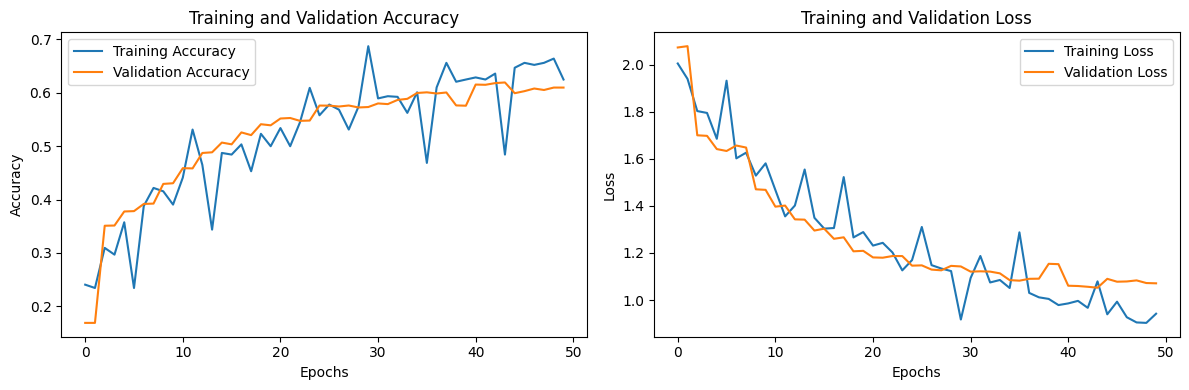

In [7]:
history = emotion_model_info.history

plt.figure(figsize=(12, 4))
# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

115/115 ━━━━━━━━━━━━━━━━━━━━ 114s 985ms/step


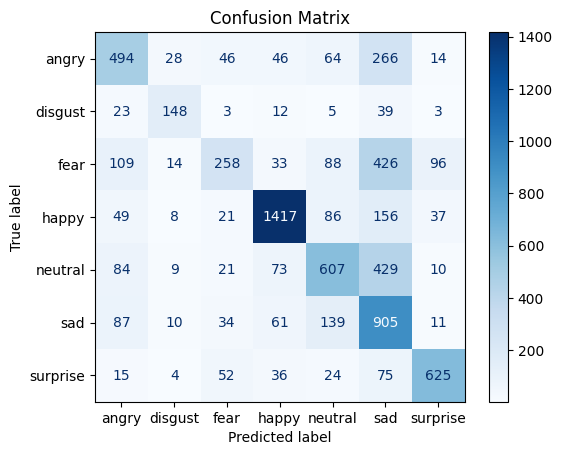

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Mengambil prediksi dari model
validation_generator.reset()  # Reset generator untuk memastikan urutan yang benar
predictions = emotion_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Mengambil label sebenarnya
true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())  # Mendapatkan nama kelas

# Menghitung confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

(48, 48)


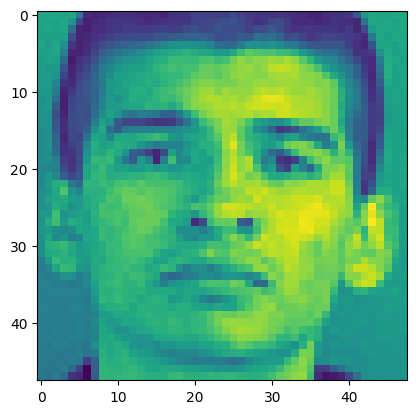

In [34]:
label_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}
img = image.load_img("D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/test/neutral/PrivateTest_1129340.jpg",target_size = (48,48),color_mode = "grayscale")
img = np.array(img)
plt.imshow(img)
print(img.shape)

In [35]:
mg = np.expand_dims(img,axis = 0) #makes image shape (1,48,48)
img = img.reshape(1,48,48,1)
result = emotion_model.predict(img)
result = list(result[0])
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.99998593), np.float32(1.4121352e-05), np.float32(0.0)]


In [36]:
img_index = result.index(max(result))
print(label_dict[img_index])
plt.show()

Neutral
